In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\91739\OneDrive\Desktop\Mainproject1\Data\Retail Sales and Profit.csv")


In [4]:
df.head()

,Order Date,Order ID,Product,Product_ean,catégorie,Purchase Address,Quantity Ordered,Price Each,Cost price,turnover,margin
0,2019-01-22 21:25:00,141234,iPhone,5.638009e+12,Vêtements,"944 Walnut St, Boston, MA 02215",1,700.00,231.0000,700.00,469.0000
1,2019-01-28 14:15:00,141235,Lightning Charging Cable,5.563320e+12,Alimentation,"185 Maple St, Portland, OR 97035",1,14.95,7.4750,14.95,7.4750
2,2019-01-17 13:33:00,141236,Wired Headphones,2.113973e+12,Vêtements,"538 Adams St, San Francisco, CA 94016",2,11.99,5.9950,23.98,NaN
3,2019-01-05 20:33:00,141237,27in FHD Monitor,3.069157e+12,Sports,"738 10th St, Los Angeles, CA 90001",1,149.99,97.4935,149.99,52.4965
4,2019-01-25 11:59:00,141238,Wired Headphones,9.692681e+12,Électronique,"387 10th St, Austin, TX 73301",1,11.99,5.9950,11.99,5.9950


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order Date        185950 non-null  str    
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  str    
 3   Product_ean       185950 non-null  float64
 4   catégorie         174793 non-null  str    
 5   Purchase Address  176653 non-null  str    
 6   Quantity Ordered  185950 non-null  int64  
 7   Price Each        185950 non-null  float64
 8   Cost price        180372 non-null  float64
 9   turnover          185950 non-null  float64
 10  margin            174793 non-null  float64
dtypes: float64(5), int64(2), str(4)
memory usage: 29.9 MB


In [6]:
df.isnull().sum()

Order Date              0
Order ID                0
Product                 0
Product_ean             0
catégorie           11157
Purchase Address     9297
Quantity Ordered        0
Price Each              0
Cost price           5578
turnover                0
margin              11157
dtype: int64

In [7]:
df.shape

(185950, 11)

In [8]:
df.columns

Index(['Order Date', 'Order ID', 'Product', 'Product_ean', 'catégorie',
       'Purchase Address', 'Quantity Ordered', 'Price Each', 'Cost price',
       'turnover', 'margin'],
      dtype='str')

### Obsevations:
**rows=185950,columns=11**


### Observation:
### Discrete Columns:

* Order ID
* Product_ean
* Quantity Ordered
---
### Continuous Numerical Columns:

* Price Each
* Cost price
* turnover
* margin
---
### Categorical Columns:

* Product
* catégorie
* Purchase Address
---
### Date/Time Column:

* Order Date

In [9]:
round(df.isnull().sum()/len(df)*100,2)

Order Date          0.0
Order ID            0.0
Product             0.0
Product_ean         0.0
catégorie           6.0
Purchase Address    5.0
Quantity Ordered    0.0
Price Each          0.0
Cost price          3.0
turnover            0.0
margin              6.0
dtype: float64

In [10]:
# renaming columns:
df.rename(columns={'catégorie':'Category'}, inplace=True)

In [11]:
df.rename(columns={"margin":"Profit"},inplace=True)

In [12]:
# Droping columns:
df.drop(columns=["Order ID","Product_ean"],inplace=True)

In [13]:
df['Category'] = df['Product'].replace({
    'iPhone':'Electronics',
    'Lightning Charging Cable':'Accessories',
    'USB-C Charging Cable':'Accessories',
    'Wired Headphones':'Accessories',
    'Bose SoundSport Headphones':'Accessories',
    '27in FHD Monitor':'Electronics',
    '34in Ultrawide Monitor':'Electronics',
    'AA Batteries (4-pack)':'Accessories',
    'AAA Batteries (4-pack)':'Accessories',
    'Macbook Pro Laptop':'Electronics',
    'ThinkPad Laptop':'Electronics',
    'LG Dryer':'Home Appliances',
    'LG Washing Machine':'Home Appliances',
    'Vareebadd Phone':'Electronics',
    'Google Phone':'Electronics',
    'Flatscreen TV':'Electronics',
    '20in Monitor':'Electronics'
})

In [88]:
df[['Product','Category']].head()

,Product,Category
0,iPhone,Electronics
1,Lightning Charging Cable,Accessories
2,Wired Headphones,Accessories
3,27in FHD Monitor,Electronics
4,Wired Headphones,Accessories


In [14]:
df.head()

,Order Date,Product,Category,Purchase Address,Quantity Ordered,Price Each,Cost price,turnover,Profit
0,2019-01-22 21:25:00,iPhone,Electronics,"944 Walnut St, Boston, MA 02215",1,700.00,231.0000,700.00,469.0000
1,2019-01-28 14:15:00,Lightning Charging Cable,Accessories,"185 Maple St, Portland, OR 97035",1,14.95,7.4750,14.95,7.4750
2,2019-01-17 13:33:00,Wired Headphones,Accessories,"538 Adams St, San Francisco, CA 94016",2,11.99,5.9950,23.98,NaN
3,2019-01-05 20:33:00,27in FHD Monitor,Electronics,"738 10th St, Los Angeles, CA 90001",1,149.99,97.4935,149.99,52.4965
4,2019-01-25 11:59:00,Wired Headphones,Accessories,"387 10th St, Austin, TX 73301",1,11.99,5.9950,11.99,5.9950


In [15]:
# Removing Null values:
df["Category"]=df["Category"].fillna(df["Category"].mode()[0])

In [16]:
df["Purchase Address"]=df["Purchase Address"].fillna(df["Purchase Address"].mode()[0])

In [17]:
df["Cost price"]=df["Cost price"].fillna(df["Cost price"].mean())

In [18]:
df["Profit"]=df["Profit"].fillna(df["Profit"].mean())

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order Date        185950 non-null  str    
 1   Product           185950 non-null  str    
 2   Category          185950 non-null  str    
 3   Purchase Address  185950 non-null  str    
 4   Quantity Ordered  185950 non-null  int64  
 5   Price Each        185950 non-null  float64
 6   Cost price        185950 non-null  float64
 7   turnover          185950 non-null  float64
 8   Profit            185950 non-null  float64
dtypes: float64(4), int64(1), str(4)
memory usage: 27.9 MB


# Observation:
* Now there is  no null values all cleared.

In [20]:
df.duplicated().sum()

np.int64(193)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

# Observation:
* 47 duplicate rows were identified and removed to improve the accuracy and reliability of the dataset.


In [23]:
# converting date column :
df["Order Date"]=pd.to_datetime(df["Order Date"])

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 185757 entries, 0 to 185949
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order Date        185757 non-null  datetime64[us]
 1   Product           185757 non-null  str           
 2   Category          185757 non-null  str           
 3   Purchase Address  185757 non-null  str           
 4   Quantity Ordered  185757 non-null  int64         
 5   Price Each        185757 non-null  float64       
 6   Cost price        185757 non-null  float64       
 7   turnover          185757 non-null  float64       
 8   Profit            185757 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memory usage: 26.0 MB


# Observation

* The dataset columns were checked and converted into appropriate data types.

In [25]:
df.describe()

,Order Date,Quantity Ordered,Price Each,Cost price,turnover,Profit
count,185757,185757.000000,185757.000000,185757.000000,185757.000000,185757.000000
mean,2019-07-18 21:42:36.039341,1.124501,184.498785,69.715800,185.591064,115.537073
min,2019-01-01 03:07:00,1.000000,2.990000,1.495000,2.990000,1.495000
25%,2019-04-16 20:56:00,1.000000,11.950000,5.975000,11.950000,5.975000
50%,2019-07-17 20:24:00,1.000000,14.950000,7.475000,14.950000,11.950000
75%,2019-10-26 08:13:00,1.000000,150.000000,97.500000,150.000000,115.469424
max,2020-01-01 05:13:00,9.000000,1700.000000,561.000000,3400.000000,2278.000000
std,NaN,0.442995,332.849954,107.835101,333.038218,218.558692


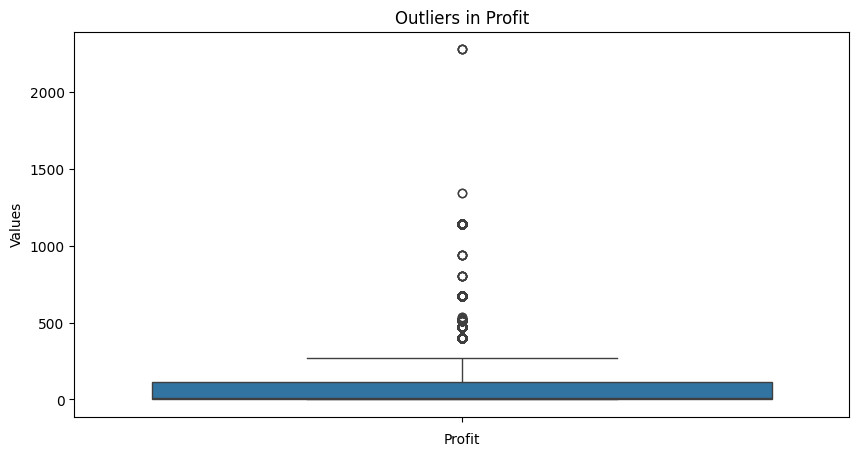

In [26]:
# detecting outliers:
plt.figure(figsize=(10,5))
sns.boxplot(df["Profit"])
plt.title("Outliers in Profit")
plt.xlabel("Profit")
plt.ylabel("Values")
plt.show()

# Obsevation:
* Profit column contain high amount of outlayers

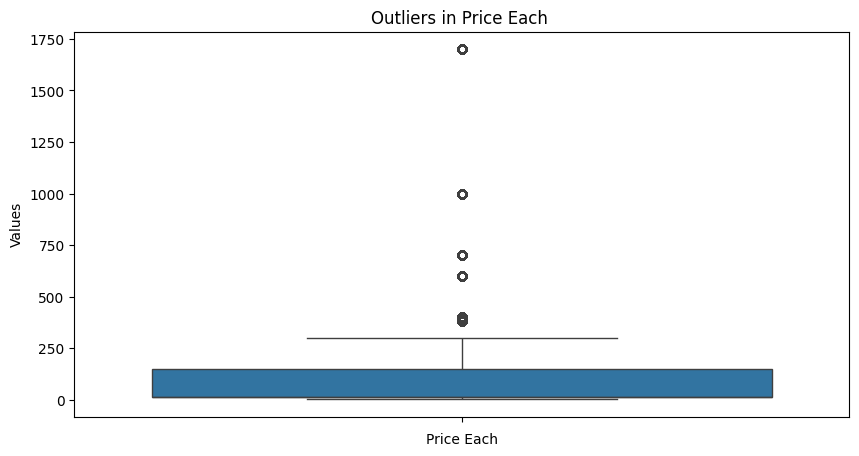

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(df["Price Each"])
plt.title("Outliers in Price Each ")
plt.xlabel("Price Each")
plt.ylabel("Values")
plt.show()

# Observation:
* In price Each column presents few outliers.

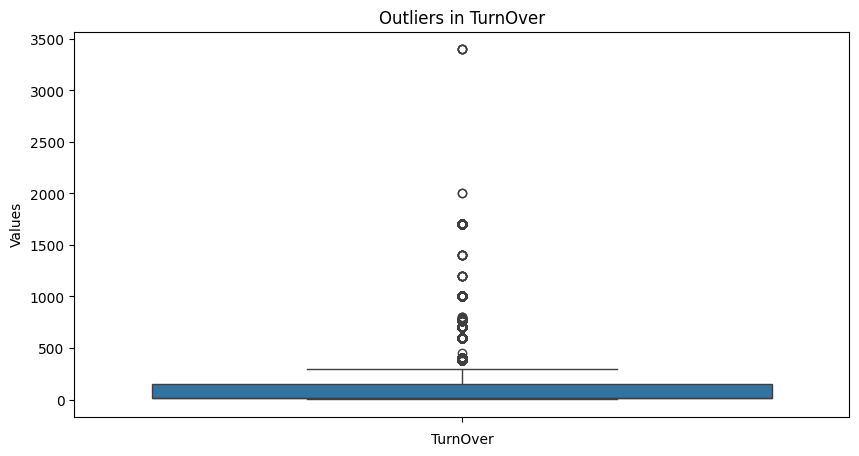

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(df["turnover"])
plt.title("Outliers in TurnOver")
plt.xlabel("TurnOver")
plt.ylabel("Values")
plt.show()

# Observation:
* TurnOver column also present high amount of outliers.


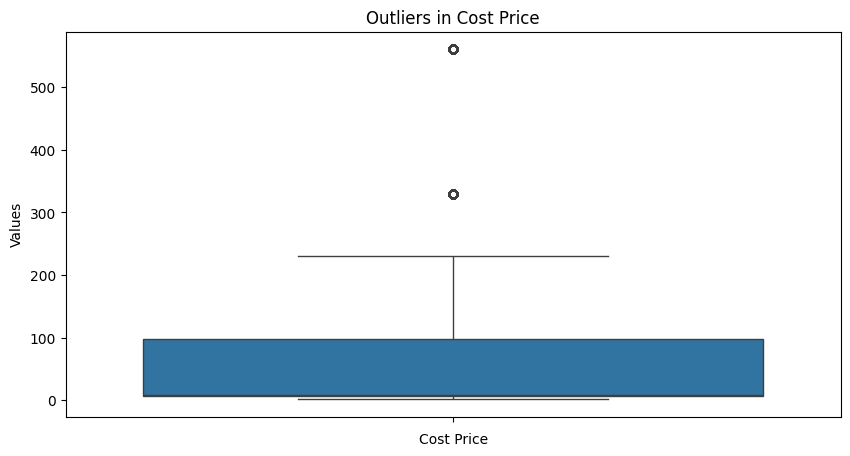

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(df["Cost price"])
plt.title("Outliers in Cost Price")

plt.xlabel("Cost Price")
plt.ylabel("Values")
plt.show()

# Observation:
* Cost pice column present only few outliers.

In [30]:
df.shape

(185757, 9)

**Univarient Analysis:**

In [31]:
# product analysis:
df["Product"].nunique()

19

# Observation:
# Unique Products:

* The dataset contains 19 unique products, indicating a retail items.

In [32]:
df["Product"].value_counts().head()

Product
USB-C Charging Cable        21871
Lightning Charging Cable    21624
AAA Batteries (4-pack)      20619
AA Batteries (4-pack)       20565
Wired Headphones            18858
Name: count, dtype: int64

# Observation:
# Most sold products:
* USB-C Charging Cable,Lightning Charging Cable,AAA Batteries(4-pack),AA Batteries(4-pack),Wired Headphones.
* These products are frequently sold and high customers demand.

In [33]:
df["Product"].value_counts().tail()

Product
ThinkPad Laptop       4126
20in Monitor          4099
Vareebadd Phone       2065
LG Washing Machine     666
LG Dryer               646
Name: count, dtype: int64

# Observation:
# Least sold products:
* ThinkPad Laptop,20in Monitor,Vareebadd Phone,LG Washing Machine,LG Dryer.
* These products are low frequency sold and low demand. 

In [34]:
# category analysis:
df["Category"].nunique()

5

In [35]:
df["Category"].value_counts()

Category
Accessories                 116842
Electronics                  45850
Apple Airpods Headphones     15527
27in 4K Gaming Monitor        6226
Home Appliances               1312
Name: count, dtype: int64

In [36]:
#Quantity analysis:
df["Quantity Ordered"].describe()

count    185757.000000
mean          1.124501
std           0.442995
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           9.000000
Name: Quantity Ordered, dtype: float64

# Observation:
* Most customers purchase products in small quantities, with single-item orders being the most common.

In [37]:
df["Quantity Ordered"].value_counts()

Quantity Ordered
1    168361
2     13322
3      2920
4       806
5       236
6        80
7        24
8         5
9         3
Name: count, dtype: int64

# Observation:
* Quantity 1 appears most frequently, indicating that customers usually purchase one product per transaction.

In [38]:
df.head()

,Order Date,Product,Category,Purchase Address,Quantity Ordered,Price Each,Cost price,turnover,Profit
0,2019-01-22 21:25:00,iPhone,Electronics,"944 Walnut St, Boston, MA 02215",1,700.00,231.0000,700.00,469.000000
1,2019-01-28 14:15:00,Lightning Charging Cable,Accessories,"185 Maple St, Portland, OR 97035",1,14.95,7.4750,14.95,7.475000
2,2019-01-17 13:33:00,Wired Headphones,Accessories,"538 Adams St, San Francisco, CA 94016",2,11.99,5.9950,23.98,115.469424
3,2019-01-05 20:33:00,27in FHD Monitor,Electronics,"738 10th St, Los Angeles, CA 90001",1,149.99,97.4935,149.99,52.496500
4,2019-01-25 11:59:00,Wired Headphones,Accessories,"387 10th St, Austin, TX 73301",1,11.99,5.9950,11.99,5.995000


In [39]:
# price Each analysis:
df["Price Each"].describe()

count    185757.000000
mean        184.498785
std         332.849954
min           2.990000
25%          11.950000
50%          14.950000
75%         150.000000
max        1700.000000
Name: Price Each, dtype: float64

In [40]:
df["Price Each"].value_counts()

Price Each
11.95      21871
14.95      21624
2.99       20619
3.84       20565
11.99      18858
150.00     15527
99.99      13305
149.99      7501
700.00      6840
600.00      6834
389.99      6226
379.99      6177
300.00      4796
1700.00     4724
999.99      4126
109.99      4099
400.00      2065
Name: count, dtype: int64

# Observation:
* Product prices range from $2.99 to $1700, showing that the dataset contains both cheap and expensive products.
* Most products have lower prices, while only a few products are very expensive.


In [41]:
# cost price analysis:
df["Cost price"].describe()

count    185757.000000
mean         69.715800
std         107.835101
min           1.495000
25%           5.975000
50%           7.475000
75%          97.500000
max         561.000000
Name: Cost price, dtype: float64

In [42]:
df["Cost price"].value_counts() 

Cost price
5.975000      21171
7.475000      20956
1.495000      20006
1.920000      19973
5.995000      18298
97.500000     15090
49.995000     12913
97.493500      7282
231.000000     6642
198.000000     6604
128.696700     6036
125.396700     5995
69.684926      5577
99.000000      4642
561.000000     4588
329.996700     4003
71.493500      3978
132.000000     2003
Name: count, dtype: int64

# Observation:
* Cost prices range from $1.49 to $561, showing that the dataset contains both low-cost and expensive products.
* Most products have lower cost prices, while a few products have very high costs.

In [43]:
# turnover analysis:
df["turnover"].describe()

count    185757.000000
mean        185.591064
std         333.038218
min           2.990000
25%          11.950000
50%          14.950000
75%         150.000000
max        3400.000000
Name: turnover, dtype: float64

In [44]:
df["turnover"].value_counts()

turnover
14.95      20342
11.95      19987
11.99      17337
150.00     15416
3.84       15322
2.99       13705
99.99      13175
149.99      7458
600.00      6846
700.00      6833
389.99      6212
379.99      6159
300.00      4887
1700.00     4720
5.98        4629
999.99      4124
109.99      4071
7.68        3873
400.00      2062
23.90       1713
8.97        1502
23.98       1380
29.90       1344
11.52       1033
11.96        524
15.36        250
35.85        157
199.98       128
35.97        128
44.85         97
19.20         69
17.94         63
299.98        43
219.98        28
20.93         22
759.98        18
23.04         16
779.98        14
47.96         13
47.80         12
1200.00        7
59.80          7
1400.00        7
23.92          5
3400.00        4
800.00         3
26.91          3
1999.98        2
299.97         2
26.88          2
71.70          1
59.75          1
450.00         1
Name: count, dtype: int64

# Observation:
* Turnover values range from $2.99 to $3400, indicating both small and high-value sales transactions.
* A few transactions generate very high revenue compared to regular sales.

In [45]:
# Profit analysis:
df["Profit"].describe()

count    185757.000000
mean        115.537073
std         218.558692
min           1.495000
25%           5.975000
50%          11.950000
75%         115.469424
max        2278.000000
Name: Profit, dtype: float64

In [46]:
df["Profit"].value_counts()


Profit
7.475000       19069
5.975000       18801
5.995000       16283
52.500000      14508
1.920000       14358
1.495000       12863
49.995000      12375
115.469424     11155
52.496500       7028
402.000000      6438
469.000000      6423
261.293300      5844
254.593300      5793
201.000000      4490
1139.000000     4433
2.990000        4374
669.993300      3918
38.496500       3843
3.840000        3662
268.000000      1950
11.950000       1599
4.485000        1414
11.990000       1279
14.950000       1253
5.760000         972
5.980000         498
7.680000         237
17.925000        144
99.990000        122
17.985000        119
105.000000       104
22.425000         85
9.600000          65
8.970000          60
104.993000        42
76.993000         24
10.465000         20
509.186600        18
11.520000         16
23.900000         12
522.586600        12
23.980000         12
804.000000         7
29.900000          7
938.000000         6
11.960000          5
2278.000000        4
536.00

# Observations:
* Profit values range from $1.49 to $2278, showing that some products generate very high profits compared to others.
* Most transactions generate lower profits, while a few high-profit products contribute significantly to overall earnings.

In [47]:
# Date analysis:

df["Order Date"].min()


Timestamp('2019-01-01 03:07:00')

In [48]:
df["Order Date"].max()

Timestamp('2020-01-01 05:13:00')

**BiVarient Analysis:**

In [49]:
df.head(5)

,Order Date,Product,Category,Purchase Address,Quantity Ordered,Price Each,Cost price,turnover,Profit
0,2019-01-22 21:25:00,iPhone,Electronics,"944 Walnut St, Boston, MA 02215",1,700.00,231.0000,700.00,469.000000
1,2019-01-28 14:15:00,Lightning Charging Cable,Accessories,"185 Maple St, Portland, OR 97035",1,14.95,7.4750,14.95,7.475000
2,2019-01-17 13:33:00,Wired Headphones,Accessories,"538 Adams St, San Francisco, CA 94016",2,11.99,5.9950,23.98,115.469424
3,2019-01-05 20:33:00,27in FHD Monitor,Electronics,"738 10th St, Los Angeles, CA 90001",1,149.99,97.4935,149.99,52.496500
4,2019-01-25 11:59:00,Wired Headphones,Accessories,"387 10th St, Austin, TX 73301",1,11.99,5.9950,11.99,5.995000


In [50]:
#groupby:
df.groupby('Category')['turnover'].sum()

Category
27in 4K Gaming Monitor       2433537.60
Accessories                  2421201.54
Apple Airpods Headphones     2345850.00
Electronics                 26487050.06
Home Appliances               787200.00
Name: turnover, dtype: float64

# Observation:
* Sports has highest turnover=10236796.22.
* Remaining categories are have equal turnover8091442.

In [51]:
df.groupby(['Category','Product'])['turnover'].sum()

Category                  Product                   
27in 4K Gaming Monitor    27in 4K Gaming Monitor        2433537.60
Accessories               AA Batteries (4-pack)          106068.48
                          AAA Batteries (4-pack)          92672.06
                          Bose SoundSport Headphones    1343565.63
                          Lightning Charging Cable       346585.85
                          USB-C Charging Cable           286118.85
                          Wired Headphones               246190.67
Apple Airpods Headphones  Apple Airpods Headphones      2345850.00
Electronics               20in Monitor                   453928.73
                          27in FHD Monitor              1131524.56
                          34in Ultrawide Monitor        2354038.05
                          Flatscreen TV                 1444500.00
                          Google Phone                  3317400.00
                          Macbook Pro Laptop            8037600.00
         

# Observation:
* Electronic products generate the highest turnover, with Vareebadd Phone and iPhone contributing the most revenue.
* Turnover is unevenly distributed, indicating that a few products drive a large portion of total sales.


In [52]:
pd.options.display.float_format = '{:,.2f}'.format

In [53]:
df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

Product
Macbook Pro Laptop           5,091,438.72
iPhone                       3,065,472.93
ThinkPad Laptop              2,651,500.42
Google Phone                 2,126,956.79
27in 4K Gaming Monitor       1,575,992.77
34in Ultrawide Monitor       1,526,286.15
Flatscreen TV                  942,981.19
Apple Airpods Headphones       878,286.55
Bose SoundSport Headphones     724,255.23
Vareebadd Phone                536,720.04
27in FHD Monitor               423,122.43
Lightning Charging Cable       319,845.69
USB-C Charging Cable           285,989.10
LG Washing Machine             257,130.37
Wired Headphones               249,901.65
LG Dryer                       249,376.90
AA Batteries (4-pack)          194,566.71
AAA Batteries (4-pack)         185,417.56
20in Monitor                   176,578.79
Name: Profit, dtype: float64

# Observation:
* MacBook Pro Laptop generated the highest total profit, followed by iPhone and ThinkPad Laptop, making them the most profitable products.
* Lower-profit products such as 20in Monitor and AA/AAA Batteries are least profit products.

In [54]:
df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

Product
AAA Batteries (4-pack)        30994
AA Batteries (4-pack)         27622
USB-C Charging Cable          23943
Lightning Charging Cable      23183
Wired Headphones              20533
Apple Airpods Headphones      15639
Bose SoundSport Headphones    13437
27in FHD Monitor               7544
iPhone                         6847
27in 4K Gaming Monitor         6240
34in Ultrawide Monitor         6195
Google Phone                   5529
Flatscreen TV                  4815
Macbook Pro Laptop             4728
ThinkPad Laptop                4128
20in Monitor                   4127
Vareebadd Phone                2068
LG Washing Machine              666
LG Dryer                        646
Name: Quantity Ordered, dtype: int64

# Observation:
* **AAA Batteries (4-pack)** recorded the highest quantity ordered, showing the strongest customer demand.
* **MacBook Pro Laptop** and **ThinkPad Laptop** had lower order quantities, indicating less frequent purchases.


In [55]:
df.groupby(df['Order Date'].dt.month)['turnover'].sum()

Order Date
1    1,821,443.90
2    2,200,739.84
3    2,805,493.26
4    3,389,259.83
5    3,152,358.92
6    2,576,325.84
7    2,646,698.03
8    2,243,290.25
9    2,096,869.61
10   3,734,972.68
11   3,198,487.89
12   4,608,899.15
Name: turnover, dtype: float64

# Observation:
* **December (Month 12)** recorded the highest turnover, indicating peak sales performance during the year.
* **January (Month 1)** had the lowest turnover, showing comparatively weaker sales activity.


In [56]:
df.groupby(["Order Date","Product"])["Profit"].sum().sort_values(ascending=False)

Order Date           Product               
2019-03-31 10:12:00  Macbook Pro Laptop       2,278.00
2019-03-30 10:47:00  Macbook Pro Laptop       2,278.00
2019-03-29 21:17:00  Macbook Pro Laptop       2,278.00
2019-04-23 19:23:00  Macbook Pro Laptop       2,278.00
2019-10-05 08:56:00  Macbook Pro Laptop       2,278.00
                                                ...   
2019-01-01 09:08:00  AAA Batteries (4-pack)       1.50
2019-01-01 09:03:00  AAA Batteries (4-pack)       1.50
2019-01-01 10:21:00  AAA Batteries (4-pack)       1.50
2019-01-01 11:07:00  AAA Batteries (4-pack)       1.50
2019-01-01 10:40:00  AAA Batteries (4-pack)       1.50
Name: Profit, Length: 181877, dtype: float64

# Observation:
* **MacBook Pro Laptop** recorded the highest profit per order (2278), making it the most profitable product in individual transactions.
* **AAA Batteries (4-pack)** generated the lowest profit per order (1.5), indicating a very low profit margin per sale.


In [57]:
df.groupby('Price Each')['Profit'].sum()

Price Each
2.99         185,417.56
3.84         194,566.71
11.95        285,989.10
11.99        249,901.65
14.95        319,845.69
99.99        724,255.23
109.99       176,578.79
149.99       423,122.43
150.00       878,286.55
300.00       942,981.19
379.99     1,526,286.15
389.99     1,575,992.77
400.00       536,720.04
600.00     2,633,464.06
700.00     3,065,472.93
999.99     2,651,500.42
1,700.00   5,091,438.72
Name: Profit, dtype: float64

In [58]:
df.groupby('Quantity Ordered')['turnover'].sum()

Quantity Ordered
1   34,092,458.92
2      323,500.10
3       41,006.10
4       11,722.72
5        3,866.25
6        1,570.56
7          514.22
8          119.60
9           80.73
Name: turnover, dtype: float64

# Observation:
* single item has highest turnover in the transactions.
* Two itemns has moderate turnover.
* Above 3 and more items has less turnover.

In [59]:
df.groupby(['Cost price','Product'])['Profit'].sum()

Cost price  Product                   
1.50        AAA Batteries (4-pack)         179,529.53
1.92        AA Batteries (4-pack)          189,258.62
5.97        USB-C Charging Cable           276,076.90
6.00        Wired Headphones               242,759.50
7.47        Lightning Charging Cable       310,389.80
49.99       Bose SoundSport Headphones     702,739.40
69.68       20in Monitor                     5,196.89
            27in 4K Gaming Monitor          48,333.31
            27in FHD Monitor                12,252.41
            34in Ultrawide Monitor          44,642.84
            AA Batteries (4-pack)            5,308.09
            AAA Batteries (4-pack)           5,888.03
            Apple Airpods Headphones        24,705.80
            Bose SoundSport Headphones      21,515.83
            Flatscreen TV                   29,842.10
            Google Phone                    74,378.57
            LG Dryer                         5,572.41
            LG Washing Machine             

# Observation:

* Products with higher cost prices, such as **MacBook Pro Laptop**, **iPhone**, and **ThinkPad Laptop**, generated the highest total profit.
* Lower-cost products like **AAA Batteries (4-pack)** and **AA Batteries (4-pack)** contributed comparatively lower profit despite their high sales volume.


In [60]:
# correlation:
df[['Quantity Ordered','Price Each','Cost price','turnover','Profit']].corr()

,Quantity Ordered,Price Each,Cost price,turnover,Profit
Quantity Ordered,1.00,-0.15,-0.17,-0.14,-0.13
Price Each,-0.15,1.00,0.97,1.00,0.97
Cost price,-0.17,0.97,1.00,0.97,0.93
turnover,-0.14,1.00,0.97,1.00,0.97
Profit,-0.13,0.97,0.93,0.97,1.00


# Observation:
* Price Each, Turnover, and Profit show a strong positive correlation (0.97–1.00), indicating that higher-priced products generate higher revenue and profit.
* Quantity Ordered has a weak negative correlation with Price, Turnover, and Profit (-0.13 to -0.17), suggesting that cheaper products are purchased more frequently.

In [61]:
# crosstab:
pd.crosstab(df["Category"],df["Product"])

Product,20in Monitor,27in 4K Gaming Monitor,27in FHD Monitor,34in Ultrawide Monitor,AA Batteries (4-pack),AAA Batteries (4-pack),Apple Airpods Headphones,Bose SoundSport Headphones,Flatscreen TV,Google Phone,LG Dryer,LG Washing Machine,Lightning Charging Cable,Macbook Pro Laptop,ThinkPad Laptop,USB-C Charging Cable,Vareebadd Phone,Wired Headphones,iPhone
Category,,,,,,,,,,,,,,,,,,,
27in 4K Gaming Monitor,0,6226,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Accessories,0,0,0,0,20565,20619,0,13305,0,0,0,0,21624,0,0,21871,0,18858,0
Apple Airpods Headphones,0,0,0,0,0,0,15527,0,0,0,0,0,0,0,0,0,0,0,0
Electronics,4099,0,7501,6177,0,0,0,0,4796,5522,0,0,0,4724,4126,0,2065,0,6840
Home Appliances,0,0,0,0,0,0,0,0,0,0,646,666,0,0,0,0,0,0,0


**Multivariant:**

In [62]:
#pivot table:
df.pivot_table(
    values='turnover',
    index='Category',
    columns=df['Order Date'].dt.month,
    aggfunc='sum'
)

Order Date,1,2,3,4,5,6,7,8,9,10,11,12
Category,,,,,,,,,,,,
27in 4K Gaming Monitor,"122,066.87","166,525.73","186,805.21","220,734.34","211,374.58","175,885.49","188,365.17","171,205.61","148,586.19","281,572.78","224,244.25","336,171.38"
Accessories,"122,038.76","153,958.24","206,486.05","235,337.20","213,473.79","175,236.93","188,769.99","155,568.68","151,307.29","264,913.40","227,134.28","326,976.93"
Apple Airpods Headphones,"122,550.00","151,800.00","197,550.00","227,550.00","204,750.00","174,750.00","183,000.00","151,200.00","144,900.00","250,350.00","226,800.00","310,650.00"
Electronics,"1,406,188.27","1,681,655.87","2,146,852.00","2,622,238.29","2,438,760.55","1,991,653.42","2,022,362.87","1,708,915.96","1,606,476.13","2,871,536.50","2,454,909.36","3,535,500.84"
Home Appliances,"48,600.00","46,800.00","67,800.00","83,400.00","84,000.00","58,800.00","64,200.00","56,400.00","45,600.00","66,600.00","65,400.00","99,600.00"


# Observation:


* **Sports** category generated the highest total turnover across most months, with the peak turnover recorded in **December (1,388,901.99)**.
* All categories show a noticeable increase in turnover during **October to December**, indicating stronger sales toward the end of the year.


In [63]:
df.pivot_table(
    values='Profit',
    index='Category',
    columns=df['Order Date'].dt.month,
    aggfunc='sum'
)

Order Date,1,2,3,4,5,6,7,8,9,10,11,12
Category,,,,,,,,,,,,
27in 4K Gaming Monitor,"78,430.85","109,093.23","121,368.07","142,964.35","135,818.37","113,614.39","121,684.12","110,916.34","96,927.92","182,820.81","145,285.64","217,068.69"
Accessories,"98,593.50","126,641.58","160,180.66","190,886.93","175,144.68","141,220.93","151,315.18","124,094.47","124,768.14","219,228.18","180,199.00","267,702.70"
Apple Airpods Headphones,"46,292.85","56,719.26","73,802.24","85,876.47","77,014.90","65,948.18","68,657.24","56,761.13","53,737.53","92,355.68","84,700.84","116,420.24"
Electronics,"882,705.35","1,045,918.45","1,350,801.18","1,630,349.38","1,528,940.88","1,248,120.90","1,264,969.80","1,067,840.90","995,238.15","1,785,594.05","1,527,635.84","2,212,942.60"
Home Appliances,"31,129.35","30,209.88","43,706.82","52,726.16","53,414.69","38,249.88","42,154.41","36,068.82","29,119.35","42,902.82","41,812.29","65,012.82"


# Observation:

* The **Sports** category generated the highest total profit across most months, with the highest profit recorded in **December (868,026.08)**.
* All categories show increased profit during **October to December**, indicating stronger profitability at the end of the year.


In [64]:
df.groupby('Product')[['Quantity Ordered','Profit']].sum().sort_values(by="Profit", ascending=False)

,Quantity Ordered,Profit
Product,,
Macbook Pro Laptop,4728,"5,091,438.72"
iPhone,6847,"3,065,472.93"
ThinkPad Laptop,4128,"2,651,500.42"
Google Phone,5529,"2,126,956.79"
27in 4K Gaming Monitor,6240,"1,575,992.77"
34in Ultrawide Monitor,6195,"1,526,286.15"
Flatscreen TV,4815,"942,981.19"
Apple Airpods Headphones,15639,"878,286.55"
Bose SoundSport Headphones,13437,"724,255.23"


# Observation:
* Macbook Pro Laptop generates the highest profit, followed by iPhone and ThinkPad Laptop, making them the most profitable products in the dataset.
* Although products like AAA Batteries and USB-C Charging Cable have high sales quantities, they contribute lower profits.


In [65]:
df.groupby('Product')[['turnover','Profit']].sum().sort_values(by="Profit", ascending=False)

,turnover,Profit
Product,,
Macbook Pro Laptop,"8,037,600.00","5,091,438.72"
iPhone,"4,792,900.00","3,065,472.93"
ThinkPad Laptop,"4,127,958.72","2,651,500.42"
Google Phone,"3,317,400.00","2,126,956.79"
27in 4K Gaming Monitor,"2,433,537.60","1,575,992.77"
34in Ultrawide Monitor,"2,354,038.05","1,526,286.15"
Flatscreen TV,"1,444,500.00","942,981.19"
Apple Airpods Headphones,"2,345,850.00","878,286.55"
Bose SoundSport Headphones,"1,343,565.63","724,255.23"


* Macbook Pro Laptop generates the highest turnover and profit, followed by iPhone and ThinkPad Laptop, making them the top-performing products in the dataset.
* Battery packs and charging cables contribute lower revenue and profit despite having high sales volumes, indicating lower profit margins.


In [66]:
df[['Quantity Ordered','Price Each', 'Cost price','turnover','Profit']].corr()

,Quantity Ordered,Price Each,Cost price,turnover,Profit
Quantity Ordered,1.00,-0.15,-0.17,-0.14,-0.13
Price Each,-0.15,1.00,0.97,1.00,0.97
Cost price,-0.17,0.97,1.00,0.97,0.93
turnover,-0.14,1.00,0.97,1.00,0.97
Profit,-0.13,0.97,0.93,0.97,1.00


# Obseravtion:
* Profit and turnover are strongly influenced by product price and cost price.
* Quantity order cannot make much effect profit and turn over because less relation.

**Visual Analysis:**

In [67]:
df.info()

<class 'pandas.DataFrame'>
Index: 185757 entries, 0 to 185949
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order Date        185757 non-null  datetime64[us]
 1   Product           185757 non-null  str           
 2   Category          185757 non-null  str           
 3   Purchase Address  185757 non-null  str           
 4   Quantity Ordered  185757 non-null  int64         
 5   Price Each        185757 non-null  float64       
 6   Cost price        185757 non-null  float64       
 7   turnover          185757 non-null  float64       
 8   Profit            185757 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memory usage: 26.0 MB


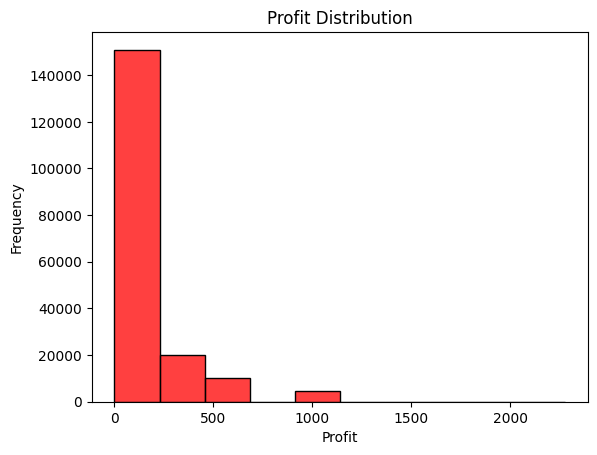

In [68]:
# Profit:
sns.histplot(df,x="Profit",bins=10,color="Red")
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

# Observation:
- Most sales transactions generate low to moderate profits, while only a few transactions generate very high profits.

Text(0.5, 1.0, 'Outlier dectction of Profit')

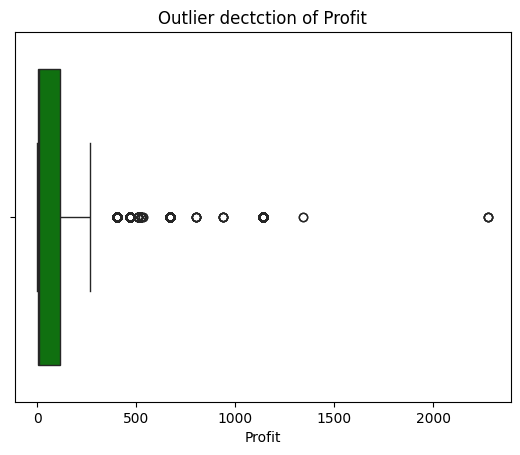

In [69]:
sns.boxplot(df,x="Profit",color="Green")
plt.title("Outlier dectction of Profit")

# Observation:
- Profit column has high amount of outliers 

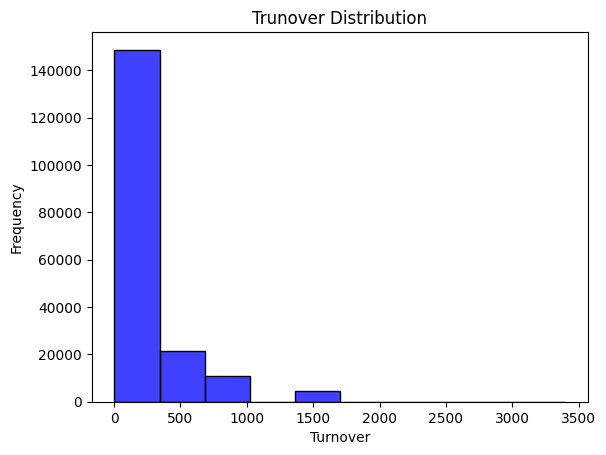

In [70]:
# turnover:
sns.histplot(df,x="turnover",bins=10,color="Blue")
plt.title("Trunover Distribution")
plt.xlabel("Turnover")
plt.ylabel("Frequency")
plt.show()

# Observation:

- Most transactions generate low turnover, while only a few transactions contribute very high sales revenue.

Text(0.5, 1.0, 'Outlier dectction of Turnover')

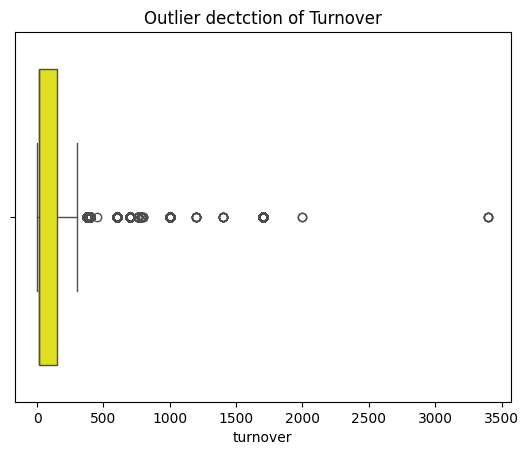

In [71]:
sns.boxplot(df,x="turnover",color="yellow")
plt.title("Outlier dectction of Turnover")


# Observation:
- Turnover also present huge amount of outliers

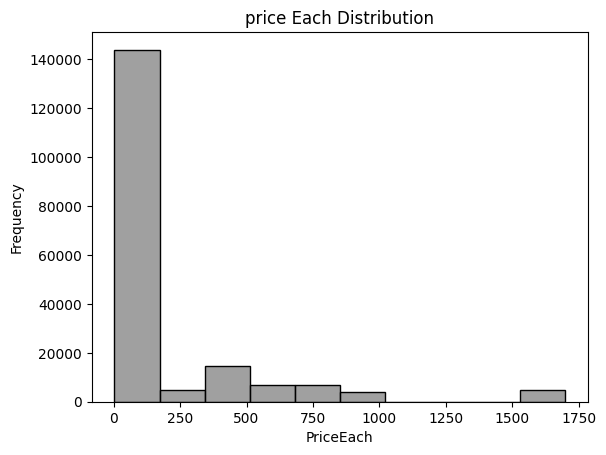

In [72]:
# Price Each:
sns.histplot(df,x="Price Each",bins=10,color="Grey")
plt.title("price Each Distribution")
plt.xlabel("PriceEach")
plt.ylabel("Frequency")
plt.show()

# Observation:
- Most products are priced in the lower price range, while only a few products have very high prices.
- The distribution is right-skewed, indicating the presence of premium-priced products.


Text(0.5, 1.0, 'Outlier dectction of Price Each')

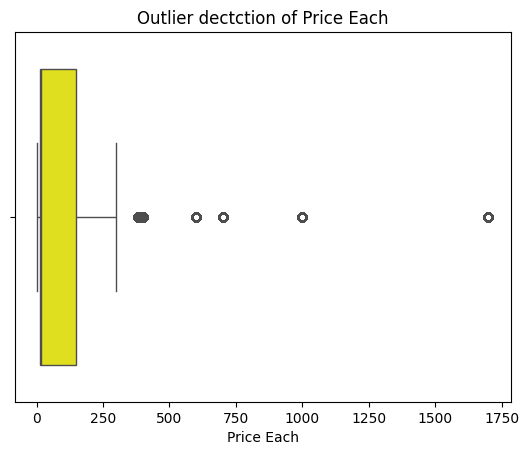

In [73]:
sns.boxplot(df,x="Price Each",color="yellow")
plt.title("Outlier dectction of Price Each")

# Observation:
- price Each has moderate outliers.

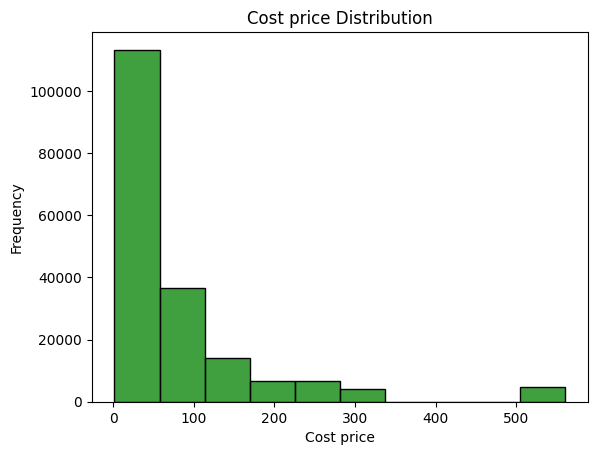

In [74]:
# Cost price:
sns.histplot(df,x="Cost price",bins=10,color="Green")
plt.title("Cost price Distribution")
plt.xlabel("Cost price")
plt.ylabel("Frequency")
plt.show()

# Observation:
- Most products have low cost prices, while only a few products have very high costs.
- The distribution is right-skewed, indicating the presence of a small number of expensive products.

Text(0.5, 1.0, 'Outlier dectction of Cost price')

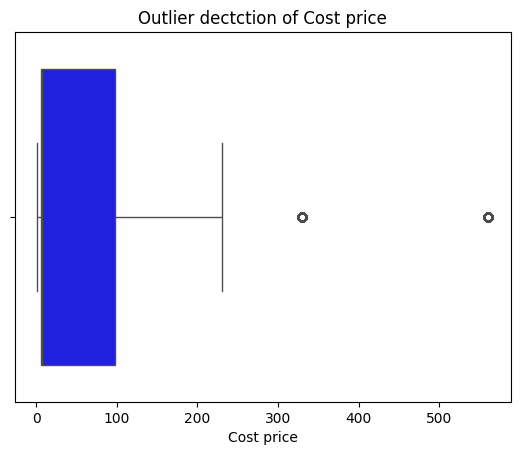

In [75]:
sns.boxplot(df,x="Cost price",color="blue")
plt.title("Outlier dectction of Cost price")

# Obseravtion:
- Cost price has low outliers.

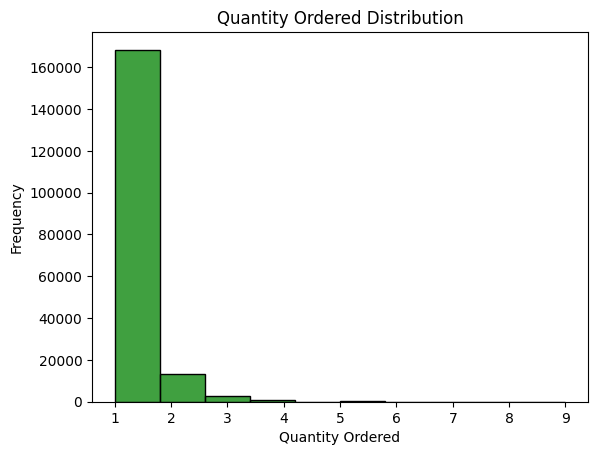

In [76]:
# Quantity Ordered:
sns.histplot(df,x="Quantity Ordered",bins=10,color="Green")
plt.title("Quantity Ordered Distribution")
plt.xlabel("Quantity Ordered")
plt.ylabel("Frequency")
plt.show()

# Observation:
- Most customers purchase only one item per transaction, making single-item orders the most common.
- Higher quantity orders are rare, indicating that bulk purchases occur less frequently.


Text(0.5, 1.0, 'Outlier dectction of Quantity Ordered')

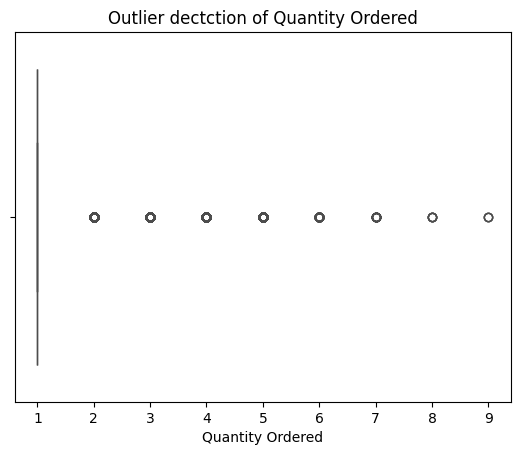

In [77]:
sns.boxplot(df,x="Quantity Ordered",color="blue")
plt.title("Outlier dectction of Quantity Ordered")

# Observation:
- Most orders contain a quantity of 1, while quantities from 2 to 9 appear as outliers in the dataset.
- These outliers represent bulk purchases and are valid business transactions, so they should not be removed.


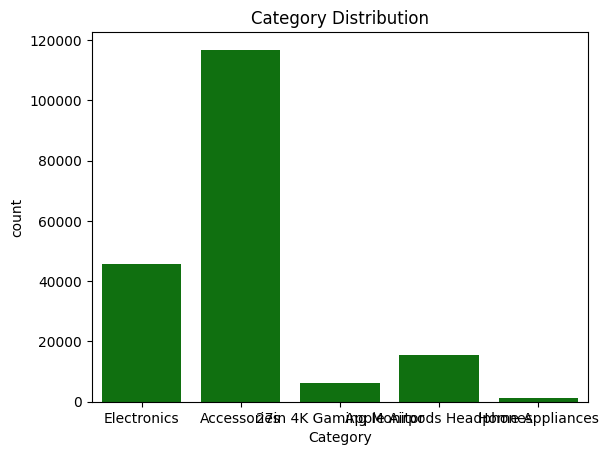

In [78]:
# Category:
sns.countplot(df,x="Category",color="Green")
plt.title("Category Distribution")
plt.show()

# Observation:
- Some categories have more transactions than others, indicating higher customer demand.

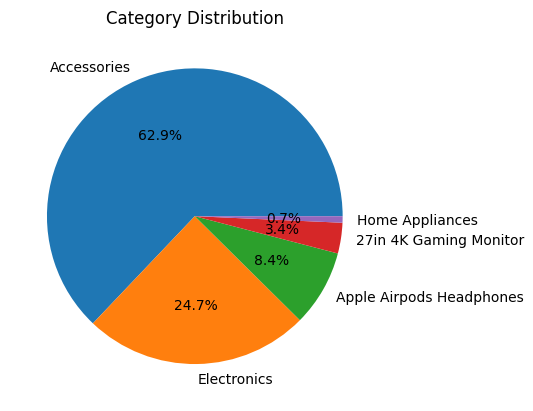

In [79]:
# Pie chart for category distribution:
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Category Distribution')
plt.show()

# Observation:
- A few categories contribute a larger share of total transactions.

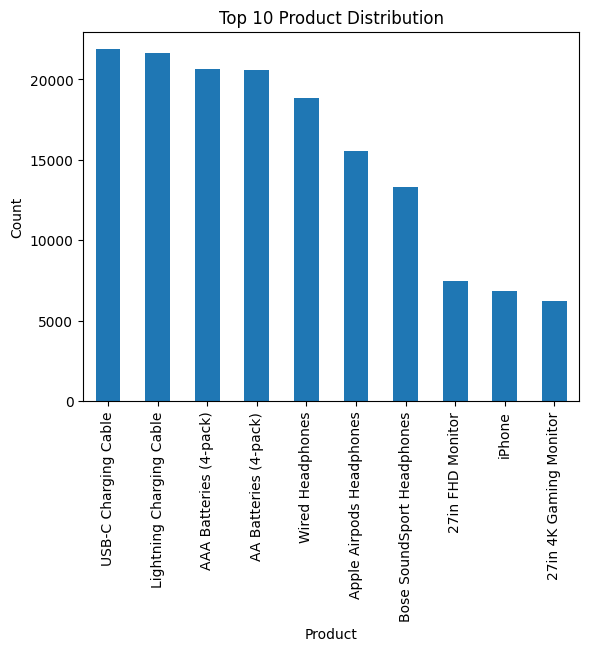

In [80]:
# Product:
top10 = df['Product'].value_counts().nlargest(10)

top10.plot(kind='bar')

plt.title("Top 10 Product Distribution")
plt.xlabel("Product")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

# Obseravtion:
- USB-C Charging Cable and Lightning Charging Cable are the most frequently ordered products, while 27in 4K Gaming Monitor has the lowest orders among the top 10 products.

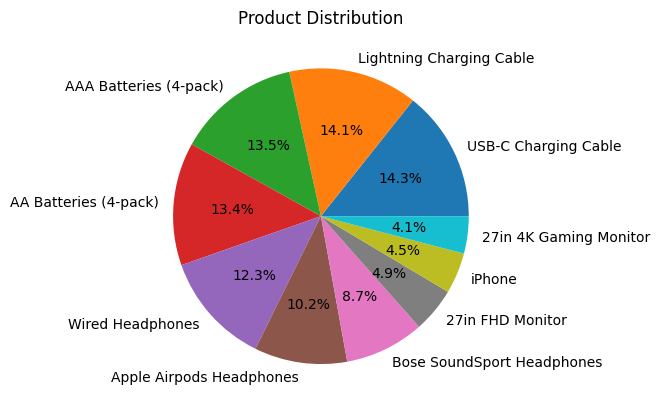

In [81]:
top10 = df['Product'].value_counts().head(10)
plt.pie(top10, labels=top10.index, autopct='%1.1f%%')
plt.title('Product Distribution')
plt.show()

# Obseravtion:
- Charging cables contribute the largest share of total orders, whereas gaming monitors contribute the smallest share among the top 10 products.

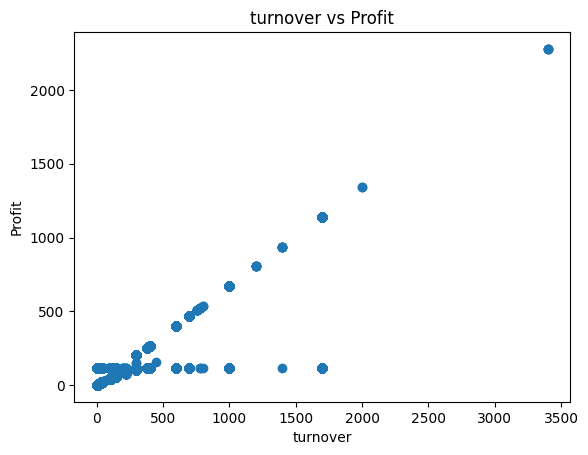

In [82]:
# sctter plot:
plt.scatter(df['turnover'], df['Profit'])
plt.xlabel('turnover')
plt.ylabel('Profit')
plt.title('turnover vs Profit')
plt.show()

# Observation:
- As turnover increases, profit also increases, showing a positive relationship between them.
- Most products have low turnover and low profit, while a few products achieve very high turnover and profit.

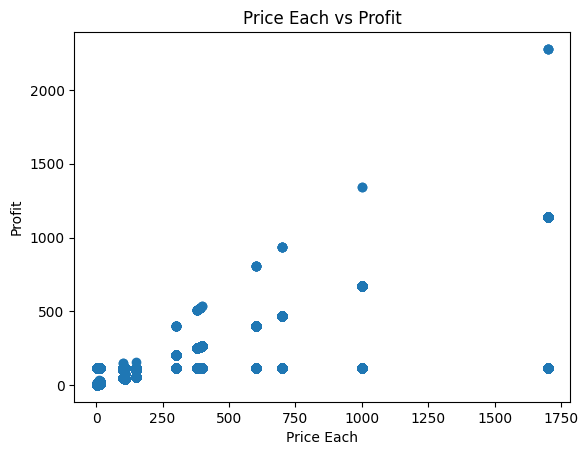

In [83]:
# sctter plot:
plt.scatter(df['Price Each'], df['Profit'])
plt.xlabel('Price Each')
plt.ylabel('Profit')
plt.title('Price Each vs Profit')
plt.show()

# Obseravtion:
- As the product price increases, profit generally tends to increase, indicating a positive relationship between price and profit.

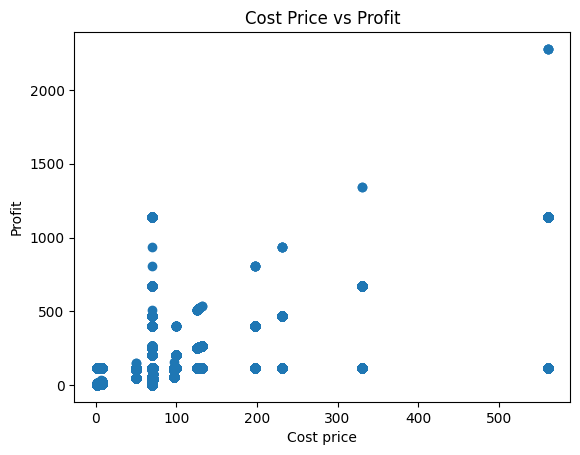

In [84]:
# sctter plot:
plt.scatter(df['Cost price'], df['Profit'])
plt.xlabel('Cost price')
plt.ylabel('Profit')
plt.title('Cost Price vs Profit')
plt.show()

# Observation:
- Higher cost-priced products tend to generate higher profits, showing a positive correlation between cost and profit.

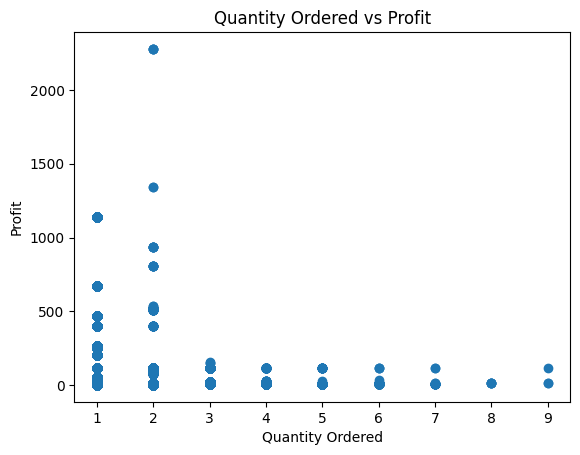

In [85]:
# sctter plot:
plt.scatter(df['Quantity Ordered'], df['Profit'])
plt.xlabel('Quantity Ordered')
plt.ylabel('Profit')
plt.title('Quantity Ordered vs Profit')
plt.show()

# Observation:
- Most of the highest profits are achieved at lower order quantities, suggesting that product value has a greater impact on profit than quantity ordered.

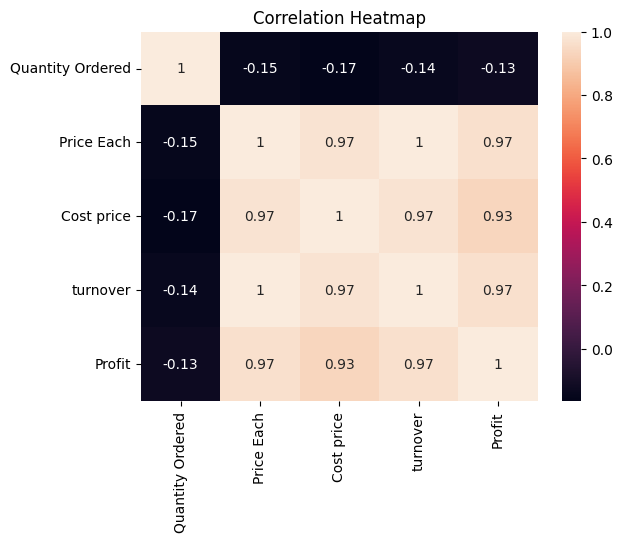

In [86]:
# Heatmap:
sns.heatmap(
    df[['Quantity Ordered',
        'Price Each',
        'Cost price',
        'turnover',
        'Profit']].corr(),
    annot=True
)
plt.title('Correlation Heatmap')
plt.show()

In [87]:
"""A heatmap shows the correlation (relationship) between numerical variables.

1 = Strong positive relationship
0 = No relationship
-1 = Strong negative relationship"""

'A heatmap shows the correlation (relationship) between numerical variables.\n\n1 = Strong positive relationship\n0 = No relationship\n-1 = Strong negative relationship'

# Observation:

- turnover and Profit show a strong positive relationship, indicating that higher sales revenue generally leads to higher profits.
- Price Each and Cost price are also positively correlated, as expensive products usually have higher costs.
* **Price Each and turnover (1.00):** Higher-priced products generate higher revenue.
* **turnover and Profit (0.97):** Higher sales revenue leads to higher profits.
* **Price Each and Profit (0.97):** Expensive products tend to generate higher profits.
* **Quantity Ordered (-0.13 to -0.17):** Quantity ordered has a weak relationship with revenue and profit.


**Probability:**




# Business Insights

1. High-priced products contribute significantly more to revenue and profit than low-priced products.

2. MacBook Pro Laptop, iPhone, and ThinkPad Laptop are the top profit-generating products.

3. Most transactions involve purchasing only one item, while bulk purchases are relatively rare.

4. Revenue and profit have a strong positive relationship, indicating that sales growth directly improves profitability.

5. A small number of premium products account for a large share of total revenue and profit.

---

# Recommendations
1. Focus marketing efforts on high-profit products such as laptops and smartphones.

2. Maintain adequate inventory levels for top-selling products to avoid stock shortages.

3. Offer bundle deals and discounts to encourage customers to purchase multiple items.

4. Monitor high-value products closely, as they contribute significantly to overall business performance.

5. Analyze seasonal sales trends to optimize inventory and promotional strategies.

---

# Conclusion

> The retail sales analysis shows that product price is a major driver of revenue and profit. Premium products generate the highest business value, while most customers purchase single items. By focusing on high-performing products and improving sales strategies, the business can increase revenue and profitability.
